<a href="https://colab.research.google.com/github/cncPomper/MMC/blob/master/MMC_lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorium 3
## Generatory liczb o wybranych rozkładach prawdopodobieństwa

---

### Piotr Kitlowski
#### indeks: 303865

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

import ipywidgets as widgets
from IPython.display import display

In [86]:
# --- GLOBALNY SEED ---
SEED = 42
np.random.seed(SEED)

In [87]:
# --- POMOCNICZE FUNKCJE ---
def timer(func):
    def wrapper(*args, **kwargs):
        start = perf_counter()
        rv = func(*args, **kwargs)  # Wywołanie właściwej funkcji
        end = perf_counter()
        elapsed = end - start
        print(f"[{func.__name__}] Czas wykonania: {elapsed:.6f} s")
        # Zwracamy zmierzony czas oraz wynik działania funkcji
        return elapsed, rv
    return wrapper

# Zadanie 1

In [98]:
# Funkcja generująca wykres, którą będziemy sterować dynamicznie
def plot_ctg(n_samples, n_sum, offset):
    # 1. Generowanie danych (Centralne Twierdzenie Graniczne)
    # n_sum to liczba zmiennych do sumy
    uniform_matrix = np.random.uniform(0, 1, (n_samples, n_sum))

    # Obliczamy sumę R_n i odejmujemy offset (standardowo n/2)
    # W zadaniu dla n=12 offset wynosił 6. Te wartości są domyślne, można je zmieniać
    y_samples = np.sum(uniform_matrix, axis=1) - offset

    # 2. Teoretyczna gęstość N(0, 1) do porównania
    def normal_pdf(x):
        return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

    # 3. Wizualizacja
    plt.figure(figsize=(12, 6))

    # Histogram wygenerowanych danych
    plt.hist(y_samples, bins=100, range=[-10, 10], density=True,
             alpha=0.6, color='#3498db', label=f'Histogram (n={n_sum}, offset={offset})')

    # Krzywa teoretyczna N(0, 1)
    x_axis = np.linspace(-10, 10, 1000)
    plt.plot(x_axis, normal_pdf(x_axis), color='#e74c3c', lw=3, label='Teoretyczna gęstość N(0, 1)')

    plt.title(f'Dynamika CTG: Suma {n_sum} zmiennych U(0,1)', fontsize=14)
    plt.xlabel('Wartość zmiennej Y', fontsize=12)
    plt.ylabel('Gęstość', fontsize=12)
    plt.ylim(0, 1.5)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Tworzenie interaktywnych przyrządów (widgets)
interactive_plot = widgets.interactive(
    plot_ctg,
    n_samples = widgets.IntSlider(min=1000, max=200000, step=1000, value=100000, description='Próbki:'),
    n_sum = widgets.IntSlider(min=1, max=50, step=1, value=12, description='n (suma):'),
    offset = widgets.FloatSlider(min=0.0, max=25.0, step=0.5, value=6.0, description='Offset:')
)

# Wyświetlenie panelu sterowania i wykresu
display(interactive_plot)

interactive(children=(IntSlider(value=100000, description='Próbki:', max=200000, min=1000, step=1000), IntSlid…

# Zadanie 2

# Box-Muller
## - Zalety: Dokładna, prosta w implementacji.
## - Wady: Wymaga obliczania kosztownych operacji trygonometrycznych oraz logarytmu naturalnego (ln) dla każdej pary liczb.

---

# Marsaglia-Bray
## - Zalety: Szybsza od podstawowego Boxa-Mullera, ponieważ unika (sin) i (cos).
## - Wady: Jest to metoda odrzutowa, więc w każdym kroku nie generuje pary liczb, co wymaga pętli while.

In [89]:
@timer
def box_muller(n):
    u1 = np.random.uniform(0, 1, n)
    u2 = np.random.uniform(0, 1, n)
    r = np.sqrt(-2 * np.log(u1))
    theta = 2 * np.pi * u2
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

@timer
def marsaglia_bray(n):
    x, y = np.zeros(n), np.zeros(n)
    count = 0
    while count < n:
        # Generujemy zapas, bo część zostanie odrzucona
        needed = n - count
        u1 = np.random.uniform(-1, 1, needed)
        u2 = np.random.uniform(-1, 1, needed)
        b = u1**2 + u2**2

        # Filtracja punktów wewnątrz koła jednostkowego
        mask = (b <= 1) & (b > 0)
        u1_v, u2_v, b_v = u1[mask], u2[mask], b[mask]

        z = np.sqrt(-2 * np.log(b_v) / b_v)

        batch_size = min(len(u1_v), n - count)
        x[count:count+batch_size] = u1_v[:batch_size] * z[:batch_size]
        y[count:count+batch_size] = u2_v[:batch_size] * z[:batch_size]
        count += batch_size
    return x, y

[box_muller] Czas wykonania: 0.150661 s
[marsaglia_bray] Czas wykonania: 0.150431 s


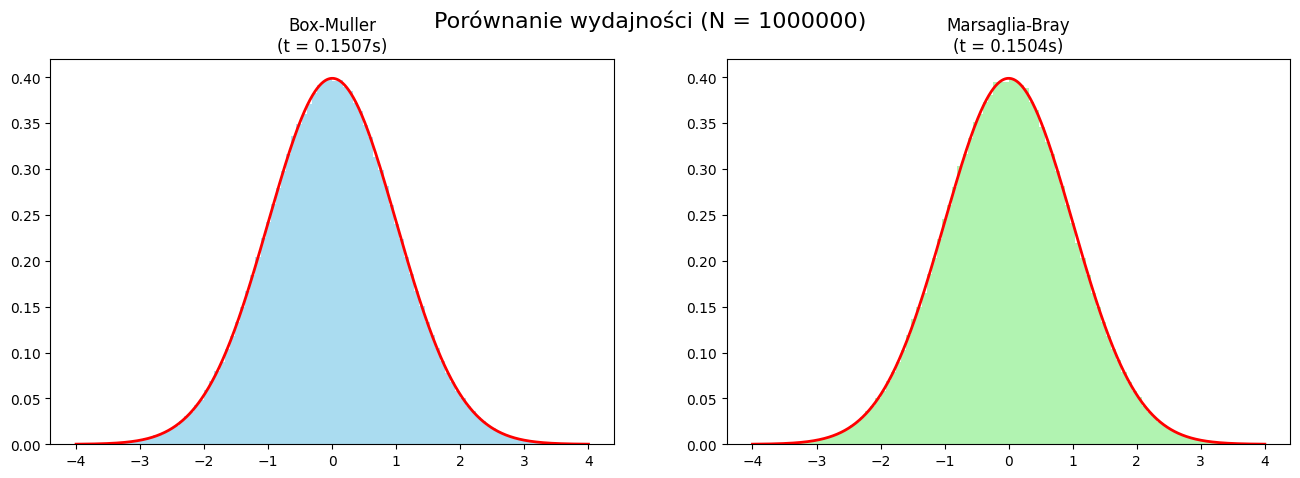

------------------------------
Szybszy algorytm: Marsaglia-Bray
Różnica: 0.000229 s


In [90]:
# --- URUCHOMIENIE I WIZUALIZACJA ---

N = 1000000

# Wywołujemy funkcje (zwracają teraz krotkę: czas, wyniki)
t_bm, (x_bm, y_bm) = box_muller(N)
t_mb, (x_mb, y_mb) = marsaglia_bray(N)

# Teoretyczna funkcja gęstości N(0,1)
def theoretical_pdf(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

# Wykresy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
x_axis = np.linspace(-4, 4, 1000)

# Box-Muller plot
ax1.hist(x_bm, bins=100, range=[-4, 4], density=True, color='skyblue', alpha=0.7)
ax1.plot(x_axis, theoretical_pdf(x_axis), 'r-', lw=2)
ax1.set_title(f'Box-Muller\n(t = {t_bm:.4f}s)')

# Marsaglia-Bray plot
ax2.hist(x_mb, bins=100, range=[-4, 4], density=True, color='lightgreen', alpha=0.7)
ax2.plot(x_axis, theoretical_pdf(x_axis), 'r-', lw=2)
ax2.set_title(f'Marsaglia-Bray\n(t = {t_mb:.4f}s)')

plt.suptitle(f"Porównanie wydajności (N = {N})", fontsize=16)
plt.show()

# Podsumowanie w konsoli
print("-" * 30)
print(f"Szybszy algorytm: {'Box-Muller' if t_bm < t_mb else 'Marsaglia-Bray'}")
print(f"Różnica: {abs(t_bm - t_mb):.6f} s")

In [91]:
def run_comparison(N):
    t_bm, (x_bm, y_bm) = box_muller(N)
    t_mb, (x_mb, y_mb) = marsaglia_bray(N)

    def theoretical_pdf(x):
        return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    x_axis = np.linspace(-4, 4, 1000)

    # Wykres Box-Muller
    ax1.hist(x_bm, bins=100, range=[-4, 4], density=True, color='skyblue', alpha=0.7)
    ax1.plot(x_axis, theoretical_pdf(x_axis), 'r-', lw=2)
    ax1.set_title(f'Box-Muller\nCzas: {t_bm:.6f} s')

    # Wykres Marsaglia-Bray
    ax2.hist(x_mb, bins=100, range=[-4, 4], density=True, color='lightgreen', alpha=0.7)
    ax2.plot(x_axis, theoretical_pdf(x_axis), 'r-', lw=2)
    ax2.set_title(f'Marsaglia-Bray\nCzas: {t_mb:.6f} s')

    plt.suptitle(f"Porównanie wydajności dla N = {N:,} (Seed: {SEED})", fontsize=14)
    plt.show()

    winner = "Box-Muller" if t_bm < t_mb else "Marsaglia-Bray"
    diff = abs(t_bm - t_mb)
    print(f"Szybszy algorytm: {winner} (różnica: {diff:.6f} s)")

# --- INTERAKTYWNE WIDGETY ---

# Używamy SelectionSlider dla N, żeby łatwiej było przełączać rzędy wielkości
n_slider = widgets.SelectionSlider(
    options=[1000, 10000, 50000, 100000, 500000, 1000000, 2000000, 4000000, 8000000, 16000000, 32000000, 64000000, 128000000],
    value=1000000,
    description='Rozmiar N:',
    disabled=False,
    continuous_update=False, # Wykres zaktualizuje się po puszczeniu suwaka
    orientation='horizontal',
    readout=True
)

interactive_ui = widgets.interactive(run_comparison, N=n_slider)
display(interactive_ui)

interactive(children=(SelectionSlider(continuous_update=False, description='Rozmiar N:', index=5, options=(100…

In [95]:
from scipy import stats

# --- GLOBALNY SEED ---
SEED = 42
np.random.seed(SEED)

# --- FUNKCJE GENERUJĄCE (bez dekoratorów dla czystości pomiaru) ---
def box_muller_raw(n):
    u1 = np.random.uniform(0, 1, n)
    u2 = np.random.uniform(0, 1, n)
    r = np.sqrt(-2 * np.log(u1))
    theta = 2 * np.pi * u2
    return r * np.cos(theta)

def marsaglia_bray_raw(n):
    x = np.zeros(n)
    count = 0
    while count < n:
        needed = n - count
        u1 = np.random.uniform(-1, 1, needed)
        u2 = np.random.uniform(-1, 1, needed)
        b = u1**2 + u2**2
        mask = (b <= 1) & (b > 0)
        u_v, b_v = u1[mask], b[mask]
        z = np.sqrt(-2 * np.log(b_v) / b_v)
        batch = (u_v * z)[:needed]
        x[count:count+len(batch)] = batch
        count += len(batch)
    return x

# --- FUNKCJA SYMULACJI TESTU ---
def run_stat_test(N, repetitions):
    bm_times = []
    mb_times = []

    # Zbieranie próbek czasu
    for _ in range(repetitions):
        # Pomiar BM
        s1 = perf_counter()
        box_muller_raw(N)
        bm_times.append(perf_counter() - s1)

        # Pomiar MB
        s2 = perf_counter()
        marsaglia_bray_raw(N)
        mb_times.append(perf_counter() - s2)

    # Obliczenia statystyczne
    t_stat, p_val = stats.ttest_ind(bm_times, mb_times)

    # Wizualizacja rozkładu czasów (Boxplot)
    plt.figure(figsize=(10, 6))
    plt.boxplot([bm_times, mb_times], labels=['Box-Muller', 'Marsaglia-Bray'])
    plt.ylabel('Czas wykonania [s]')
    plt.title(f'Rozkład czasów wykonania (N={N:,}, prób={repetitions})')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Wyniki
    print(f"{'='*40}")
    print(f"Średni czas BM: {np.mean(bm_times):.6f} s")
    print(f"Średni czas MB: {np.mean(mb_times):.6f} s")
    print(f"p-wartość testu t-Studenta: {p_val:.6f}")

    if p_val < 0.05:
        print("✅ Wynik: Różnica jest statystycznie istotna (p < 0.05).")
        winner = "Box-Muller" if np.mean(bm_times) < np.mean(mb_times) else "Marsaglia-Bray"
        print(f"🏆 Statystycznie szybszy: {winner}")
    else:
        print("❌ Wynik: Brak istotnej różnicy (p >= 0.05). Algorytmy działają podobnie.")
    print(f"{'='*40}")

# --- INTERFEJS ---
ui = widgets.interactive(
    run_stat_test,
    N = widgets.SelectionSlider(
        options=[10**4, 10**5, 10**6],
        value=10**5,
        description='Rozmiar N:'
    ),
    repetitions = widgets.IntSlider(
        min=5, max=100, step=5, value=20,
        description='Liczba pomiarów:'
    )
)

display(ui)

interactive(children=(SelectionSlider(description='Rozmiar N:', index=1, options=(10000, 100000, 1000000), val…

# Zadanie 3

[rejection_method] Czas wykonania: 0.992456 s
[superposition_method] Czas wykonania: 0.006758 s


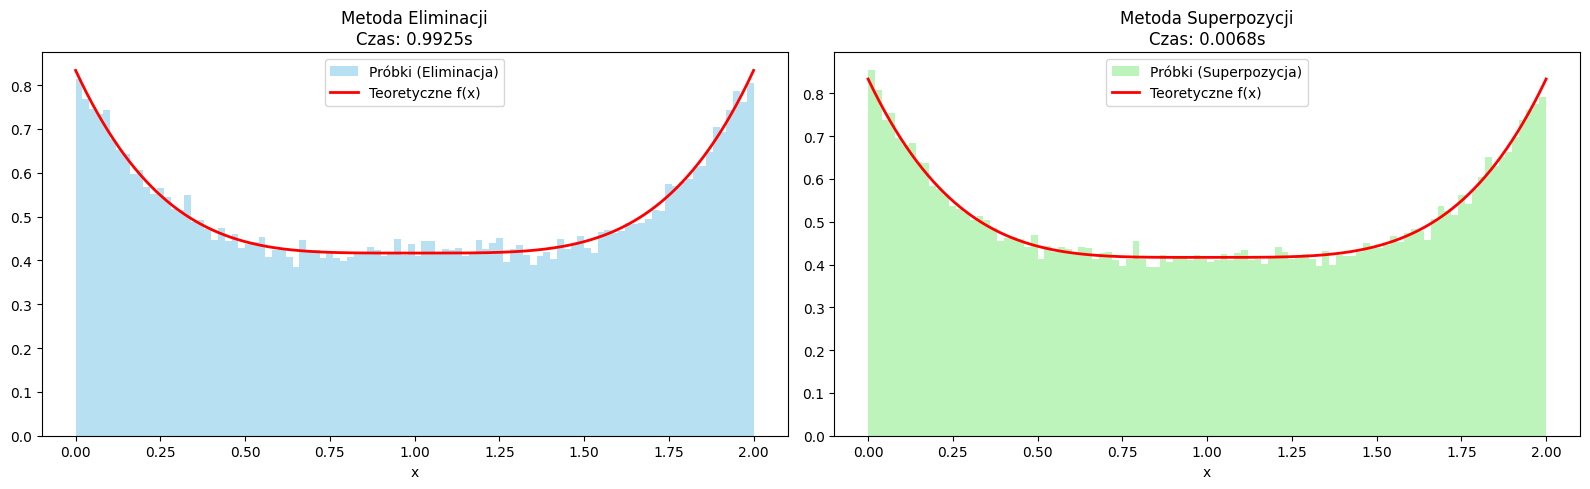

----------------------------------------
Wynik porównania: Metoda superpozycji jest ok. 146.86x szybsza.


In [93]:
# Definicja docelowej funkcji gęstości prawdopodobieństwa (PDF)
def f_pdf(x):
    return (5/12) * (1 + (x - 1)**4)

# Bezpieczne potęgowanie 1/5 dla liczb ujemnych (zastępuje problematyczne pow())
def root5(x):
    return np.sign(x) * (np.abs(x)**(1/5))

# --- METODA ELIMINACJI (Acceptance-Rejection) ---
@timer
def rejection_method(n):
    x_min, x_max = 0, 2
    # Maksimum funkcji f(x) na przedziale [0, 2] wynosi 5/6 (dla x=0 lub x=2)
    f_max = 5/6

    results = []
    while len(results) < n:
        u1 = np.random.uniform(x_min, x_max)
        u2 = np.random.uniform(0, f_max)

        if u2 < f_pdf(u1):
            results.append(u1)

    return np.array(results)

# --- METODA SUPERPOZYCJI (Composition Method) ---
@timer
def superposition_method(n):
    # Generujemy zmienne pomocnicze
    u1 = np.random.uniform(0, 2, n)
    u2 = np.random.uniform(0, 1, n)

    # X = U1, gdy U2 < 5/6
    # X = 1 + (U1 - 1)^(1/5), gdy U2 >= 5/6
    # Wykorzystujemy wektoryzację numpy zamiast pętli
    x = np.where(u2 < 5/6,
                 u1,
                 1 + root5(u1 - 1))
    return x

# --- SYMULACJA I WIZUALIZACJA ---

N = 100000  # Liczba próbek

# Uruchomienie metod
t_rej, data_rej = rejection_method(N)
t_sup, data_sup = superposition_method(N)

# Przygotowanie wykresów
x_axis = np.linspace(0, 2, 1000)
y_axis = f_pdf(x_axis)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Wykres dla metody eliminacji
ax1.hist(data_rej, bins=100, density=True, color='skyblue', alpha=0.6, label='Próbki (Eliminacja)')
ax1.plot(x_axis, y_axis, 'r-', lw=2, label='Teoretyczne f(x)')
ax1.set_title(f"Metoda Eliminacji\nCzas: {t_rej:.4f}s")
ax1.set_xlabel("x")
ax1.legend()

# Wykres dla metody superpozycji
ax2.hist(data_sup, bins=100, density=True, color='lightgreen', alpha=0.6, label='Próbki (Superpozycja)')
ax2.plot(x_axis, y_axis, 'r-', lw=2, label='Teoretyczne f(x)')
ax2.set_title(f"Metoda Superpozycji\nCzas: {t_sup:.4f}s")
ax2.set_xlabel("x")
ax2.legend()

plt.tight_layout()
plt.show()

# Porównanie wydajności
speedup = t_rej / t_sup
print("-" * 40)
print(f"Wynik porównania: Metoda superpozycji jest ok. {speedup:.2f}x szybsza.")

In [94]:
def run_simulation(N):
    t_rej, data_rej = rejection_method(N)
    t_sup, data_sup = superposition_method(N)

    x_axis = np.linspace(0, 2, 1000)
    y_axis = f_pdf(x_axis)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Plot: Eliminacja
    ax1.hist(data_rej, bins=80, range=[0, 2], density=True, color='skyblue', alpha=0.6)
    ax1.plot(x_axis, y_axis, 'r-', lw=2)
    ax1.set_title(f"Metoda Eliminacji\nCzas: {t_rej:.5f} s")

    # Plot: Superpozycja
    ax2.hist(data_sup, bins=80, range=[0, 2], density=True, color='lightgreen', alpha=0.6)
    ax2.plot(x_axis, y_axis, 'r-', lw=2)
    ax2.set_title(f"Metoda Superpozycji\nCzas: {t_sup:.5f} s")

    plt.suptitle(f"Analiza wydajności dla N = {N:,}", fontsize=14)
    plt.show()

    speedup = t_rej / t_sup if t_sup > 0 else 0
    print(f"Metoda Superpozycji jest {speedup:.2f}x szybsza niż Eliminacja.")

# --- WIDGETY ---

n_slider_3 = widgets.SelectionSlider(
    options=[1000, 5000, 10000, 50000, 100000, 500000, 1000000],
    value=100000,
    description='Rozmiar N:',
    continuous_update=False,
    style={'description_width': 'initial'}
)

ui_3 = widgets.interactive(run_simulation, N=n_slider_3)
display(ui_3)

interactive(children=(SelectionSlider(continuous_update=False, description='Rozmiar N:', index=4, options=(100…